# 0. Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import os
import json

In [3]:
df = pd.read_csv("../Data/churn_processed.csv")
df = df[df['Churn'] == 1]
df = df.drop(columns = ["CustomerID", "Churn"])
df_churn = df.copy()

# 1. Preprocessing

## a. Encode

In [4]:
df_churn['CityTier'] = df_churn['CityTier'].astype('str')
df_encode = pd.get_dummies(df_churn, drop_first = True)
df_encode.head()

,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,...,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Others,PreferedOrderCat_Phone,MaritalStatus_Married,MaritalStatus_Single
7,1.0,17.0,4.0,5,4,3,1,26.0,2.0,2.0,...,False,False,False,False,False,False,False,True,False,True
24,1.0,17.0,4.0,5,4,3,1,26.0,1.0,2.0,...,False,False,False,False,False,False,False,True,False,True
40,9.0,16.0,3.0,4,4,2,1,25.0,1.0,1.0,...,False,False,False,False,False,False,False,True,False,True
58,9.0,16.0,3.0,4,4,2,1,25.0,0.0,1.0,...,False,False,False,False,False,False,False,True,False,True
68,1.0,14.0,4.0,6,3,3,1,25.0,2.0,2.0,...,True,False,False,True,False,True,False,False,False,True


## b. Scale

In [5]:
col = df_encode.select_dtypes(include = 'number').columns[1:]
df_encode_scale = df_encode.copy()

for c in col:
    m = df_encode[c].mean()
    sd = df_encode[c].std()
    df_encode_scale[c] = (df_encode[c] - m)/sd
df_encode_scale.head()

,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,...,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Others,PreferedOrderCat_Phone,MaritalStatus_Married,MaritalStatus_Single
7,1.0,0.017310,1.539432,1.05056,0.454315,-0.525522,0.930176,2.743215,0.152475,-0.290094,...,False,False,False,False,False,False,False,True,False,True
24,1.0,0.017310,1.539432,1.05056,0.454315,-0.525522,0.930176,2.743215,-0.375066,-0.290094,...,False,False,False,False,False,False,False,True,False,True
40,9.0,-0.103353,0.053300,0.06449,0.454315,-0.883936,0.930176,2.478983,-0.375066,-0.649114,...,False,False,False,False,False,False,False,True,False,True
58,9.0,-0.103353,0.053300,0.06449,0.454315,-0.883936,0.930176,2.478983,-0.902607,-0.649114,...,False,False,False,False,False,False,False,True,False,True
68,1.0,-0.344681,1.539432,2.03663,-0.290824,-0.525522,0.930176,2.478983,0.152475,-0.290094,...,True,False,False,True,False,True,False,False,False,True


## c. PCA

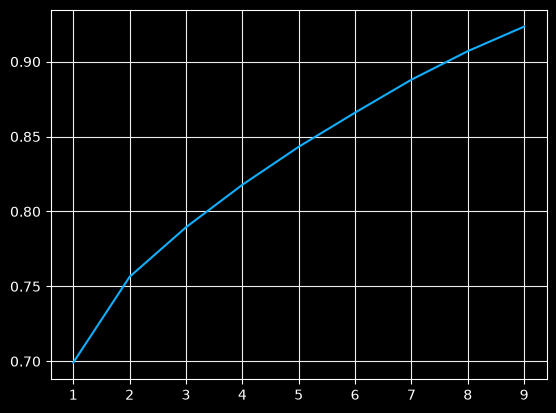

In [ ]:
explain_variance = []
for i in range (1, 10):
  pca = PCA(n_components = i)
  pca.fit(df_encode_scale)
  explain_variance.append(sum(pca.explained_variance_ratio_))
plt.style.use('dark_background')
sns.lineplot(x = list(range(1,10)), y = explain_variance, color = "#12aeff")
plt.grid(color = "#eeeeee")

Ideal number of components here is 4 (explain ~ 82% of variance)

In [7]:
pca = PCA(n_components = 4)
pca.fit(df_encode_scale)
PCA_ds = pd.DataFrame(pca.transform(df_encode_scale), columns = (["col1","col2", "col3", "col4"]))
PCA_ds.head()

,col1,col2,col3,col4
0,-2.978325,-0.203122,2.456265,1.235288
1,-2.992732,-0.465093,2.518772,1.227713
2,4.928247,-2.022938,1.077655,1.782544
3,4.913840,-2.284909,1.140162,1.774970
4,-2.859366,1.424730,2.493237,0.474670


## c1. PCA scale

In [8]:
PCA_scale = PCA_ds.copy()

for c in PCA_ds.columns:
    m = PCA_ds[c].mean()
    sd = PCA_ds[c].std()
    PCA_scale[c] = (PCA_ds[c] - m)/sd
PCA_scale.head()

,col1,col2,col3,col4
0,-0.541815,-0.129089,2.055101,1.115759
1,-0.544436,-0.295578,2.107400,1.108917
2,0.896543,-1.285627,0.901649,1.610062
3,0.893922,-1.452116,0.953947,1.603220
4,-0.520174,0.905451,2.086035,0.428740


## c2. PCA norm

In [9]:
PCA_norm = PCA_ds.copy()

for c in PCA_ds.columns:
    mn = PCA_ds[c].min()
    mx = PCA_ds[c].max()
    PCA_norm[c] = (PCA_ds[c] - mn)/(mx - mn)
PCA_norm.head()

,col1,col2,col3,col4
0,0.049711,0.246172,0.852679,0.651776
1,0.049047,0.224777,0.860535,0.650462
2,0.413981,0.097549,0.679411,0.746723
3,0.413318,0.076154,0.687267,0.745409
4,0.055192,0.379117,0.857325,0.519812


# 2. K-means

## a. Choose k

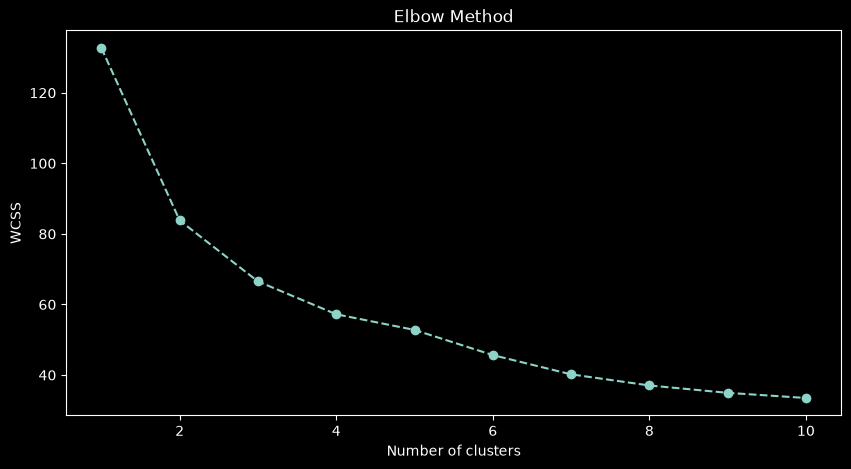

In [10]:
ss = []
max_clusters = 10
for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 10)
    kmeans.fit(PCA_norm)
    ss.append(kmeans.inertia_)

# Plot the Elbow method
plt.figure(figsize = (10,5))
plt.plot(range(1, max_clusters + 1), ss, marker = 'o', linestyle = '--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

We choose k = 2

In [11]:
kmeans = KMeans(n_clusters = 2, init = 'k-means++', random_state = 10)
kmeans.fit(PCA_norm)
PCA_norm['cluster'] = kmeans.labels_
print(PCA_norm['cluster'].value_counts(normalize = True))

cluster
1    0.735232
0    0.264768
Name: proportion, dtype: float64


## b. Clusters visualization

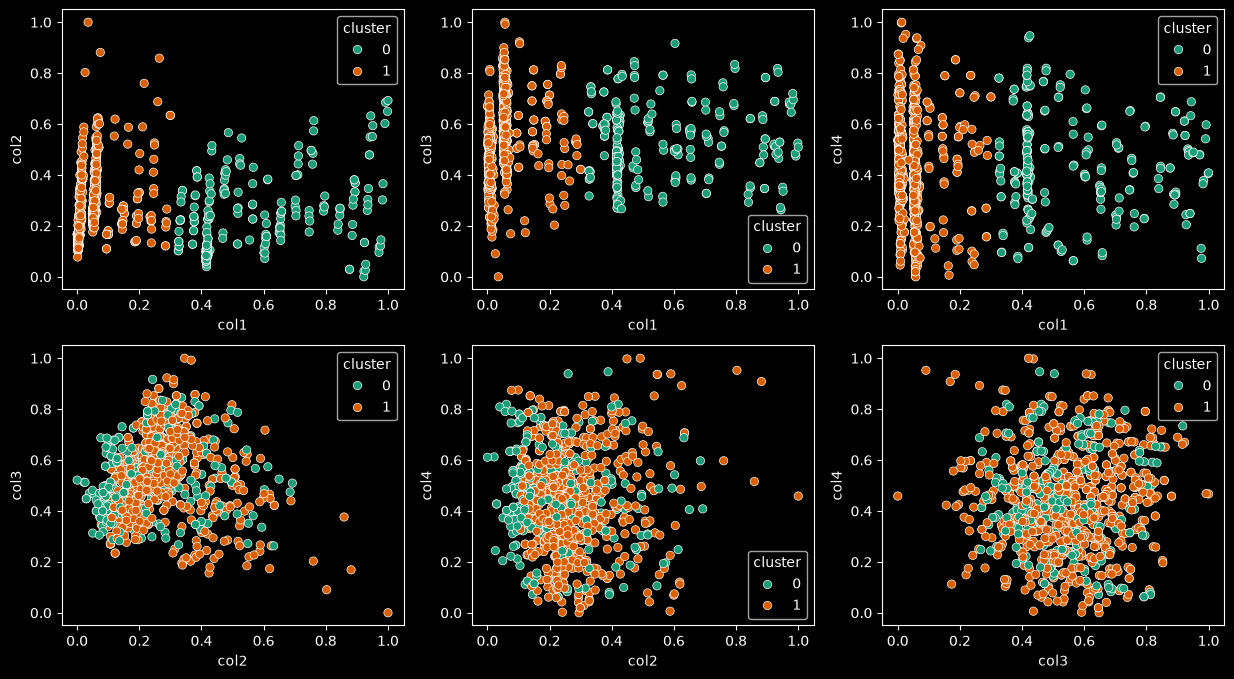

In [12]:
sns.set_palette('Dark2')
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (15,8))
sns.scatterplot(data = PCA_norm, x = "col1", y = "col2", hue = "cluster", ax = axes[0,0])
sns.scatterplot(data = PCA_norm, x = "col1", y = "col3", hue = "cluster", ax = axes[0,1])
sns.scatterplot(data = PCA_norm, x = "col1", y = "col4", hue = "cluster", ax = axes[0,2])
sns.scatterplot(data = PCA_norm, x = "col2", y = "col3", hue = "cluster", ax = axes[1,0])
sns.scatterplot(data = PCA_norm, x = "col2", y = "col4", hue = "cluster", ax = axes[1,1])
sns.scatterplot(data = PCA_norm, x = "col3", y = "col4", hue = "cluster", ax = axes[1,2])
plt.show()

# 3. EDA

In [13]:
df_churn['cluster'] = kmeans.labels_
num_col = df_churn.select_dtypes(include = "number").columns
obj_col = df_churn.select_dtypes(exclude = "number").columns

## a. Num col

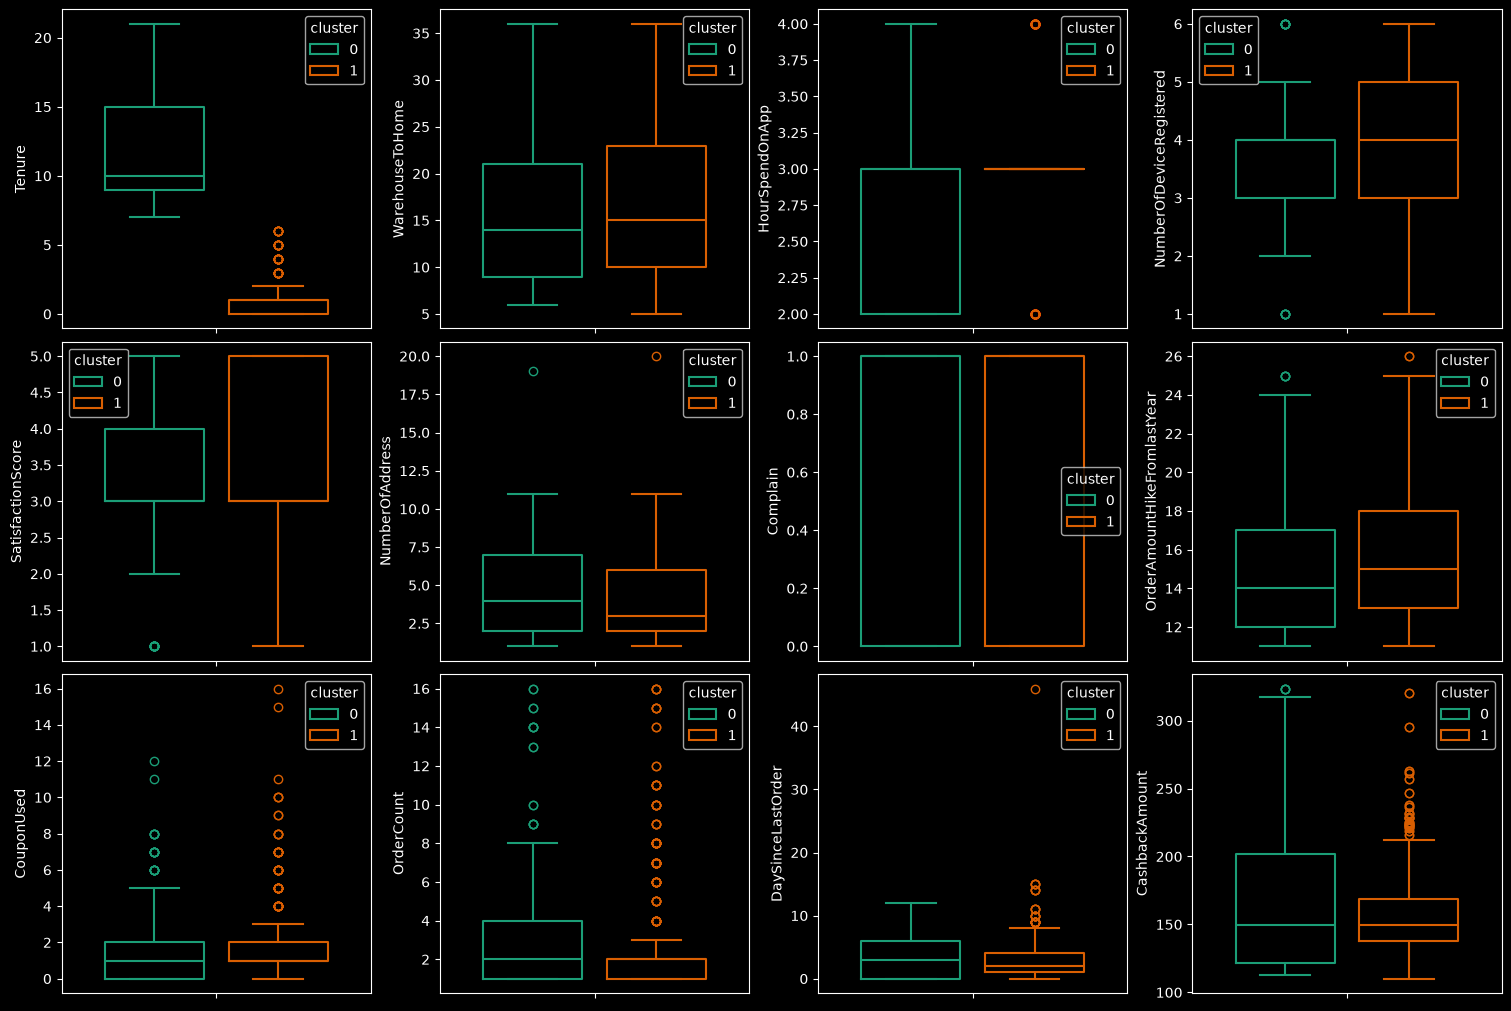

In [14]:
sns.set_palette('Dark2')
fig, axes = plt.subplots(nrows = 3, ncols = 4, figsize = (15, 10), constrained_layout = True)
axes = axes.ravel()
for i in range(len(num_col[:-1])):
    sns.boxplot(data = df_churn, y = num_col[i], hue = "cluster",
                #color = "#12aeff", linecolor = "#ffffff",
                fill = False, linewidth = 1.5, gap = 0.2, ax = axes[i])
plt.show()

## b. Obj col

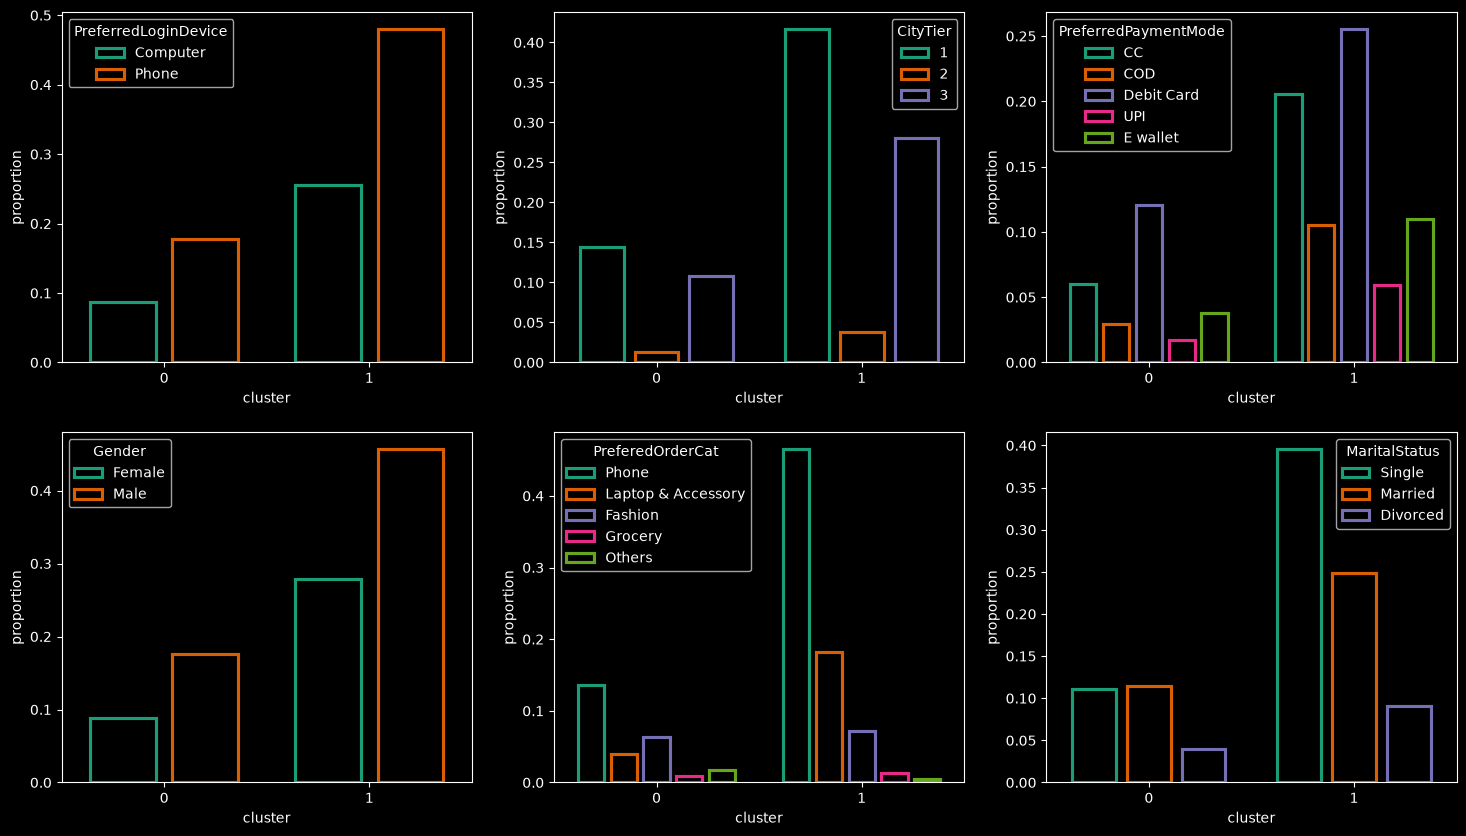

In [31]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (18, 10))
axes = axes.ravel()
for i in range(len(obj_col)):
    sns.countplot(data = df_churn, x = "cluster", hue = obj_col[i],
                  stat = 'proportion', fill = False, gap = 0.2, ax = axes[i])
plt.show()

Cluster proportion: 1: 73.5%; 0: 26.5%

Key differences between 2 clusters:
- Tenure (cluster 1 has lower Tenure)
- Marital status (cluster 1 has lower Married rate)

## c. Key features

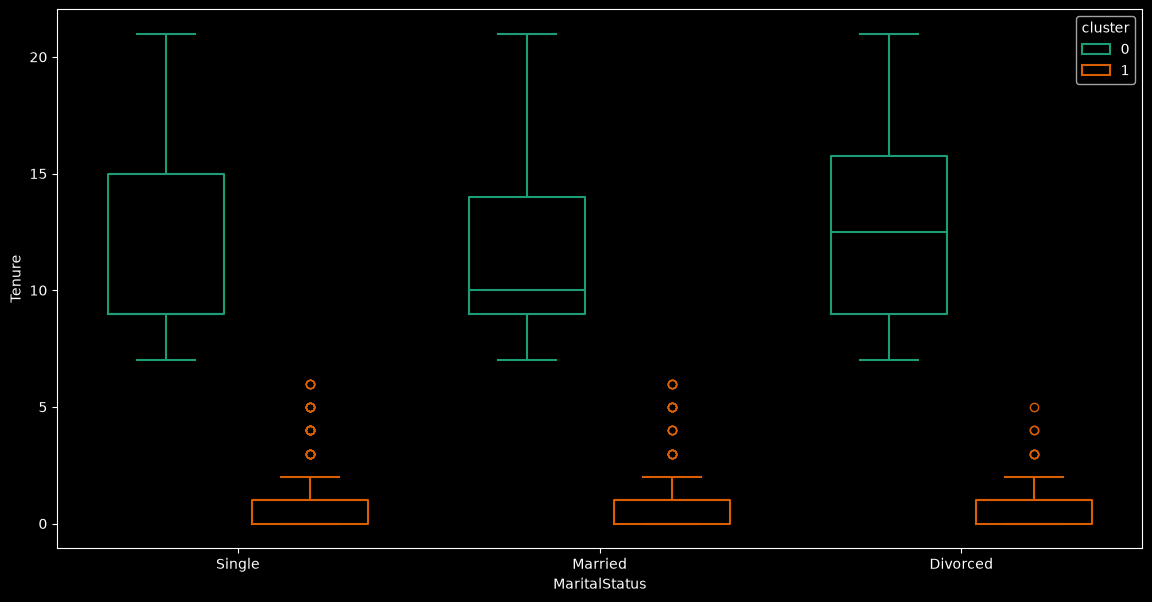

In [39]:
plt.figure(figsize = (14, 7))
sns.boxplot(data = df_churn,
            x = "MaritalStatus", y = "Tenure", hue = "cluster", 
            fill = False, linewidth = 1.5, gap = 0.2)
plt.show()

There are no significant differences or insights when combining Tenure & Marital status

Ideal churned customer segmentation:
- Segment 1: low tenure (<7)
- Segment 2: moderate & high tenure (≥7)